<a href="https://colab.research.google.com/github/abdul5675/DSA0205--Computer-Vision-/blob/main/CO2_AT_1_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Histogram:
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2]

Equalization Mapping:
0 -> 0
1 -> 0
2 -> 1
3 -> 2
4 -> 3
5 -> 4
6 -> 5
7 -> 6
8 -> 7
9 -> 8
10 -> 9
11 -> 10
12 -> 11
13 -> 12
14 -> 13
15 -> 15


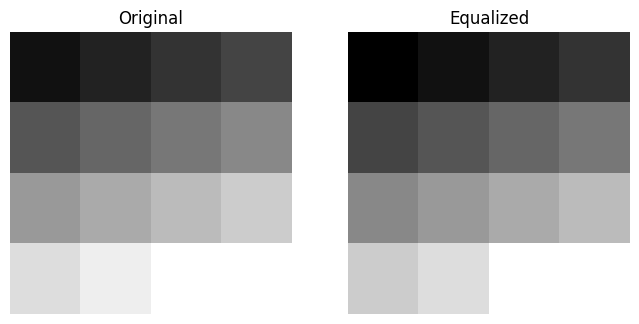

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 4-bit image (values 0-15)
img = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9,10,11,12],
    [13,14,15,15]
], dtype=np.uint8)

L = 16

# Histogram
hist = np.zeros(L, dtype=int)
for pixel in img.flatten():
    hist[pixel] += 1

print("Histogram:")
print(hist)

# PDF
pdf = hist / img.size

# CDF
cdf = np.cumsum(pdf)

# Mapping
mapping = np.floor((L - 1) * cdf).astype(np.uint8)

print("\nEqualization Mapping:")
for i in range(L):
    print(f"{i} -> {mapping[i]}")

# Equalized Image
equalized = mapping[img]

# Display
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=15)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(equalized, cmap='gray', vmin=0, vmax=15)
plt.title("Equalized")
plt.axis('off')

plt.show()

/tmp/ipykernel_479/3013074417.py:12: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
/tmp/ipykernel_479/3013074417.py:12: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))


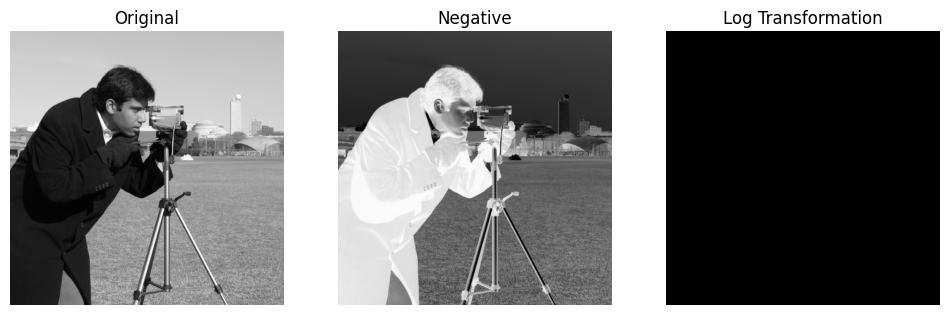

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

# Negative
negative = 255 - img

# Log Transformation
c = 255 / np.log(1 + np.max(img))
log_image = c * np.log(1 + img.astype(np.float32))
log_image = np.array(log_image, dtype=np.uint8)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(negative, cmap='gray')
plt.title("Negative")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(log_image, cmap='gray')
plt.title("Log Transformation")
plt.axis('off')

plt.show()

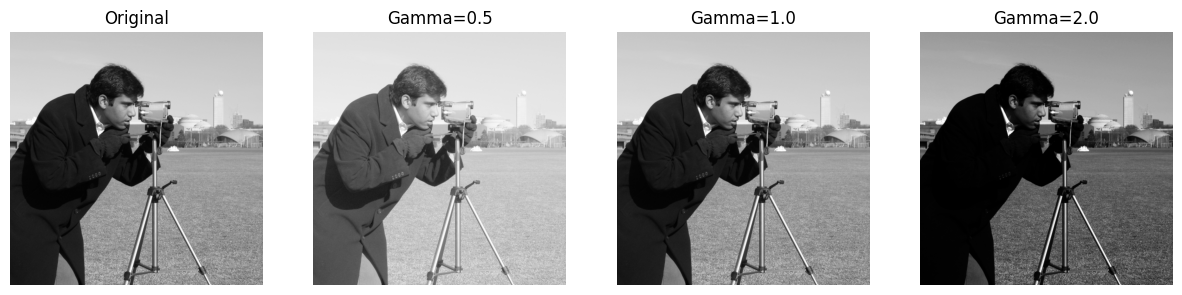

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

img_norm = img / 255.0

gammas = [0.5, 1.0, 2.0]

plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

for i, gamma in enumerate(gammas):
    gamma_img = np.power(img_norm, gamma)
    gamma_img = (gamma_img * 255).astype(np.uint8)

    plt.subplot(1,4,i+2)
    plt.imshow(gamma_img, cmap='gray')
    plt.title(f"Gamma={gamma}")
    plt.axis("off")

plt.show()

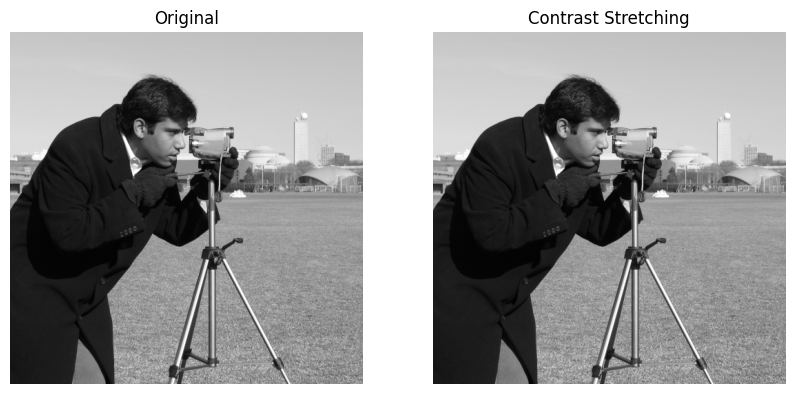

In [5]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

contrast = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(contrast, cmap='gray')
plt.title("Contrast Stretching")
plt.axis("off")

plt.show()

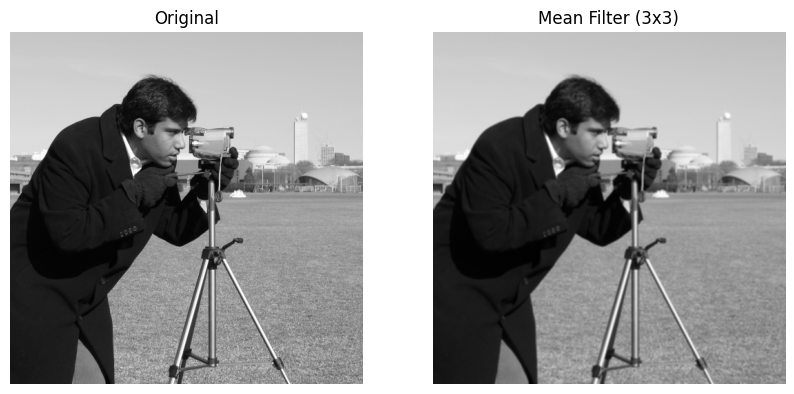

In [6]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

mean = cv2.blur(img, (3,3))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mean, cmap='gray')
plt.title("Mean Filter (3x3)")
plt.axis("off")

plt.show()

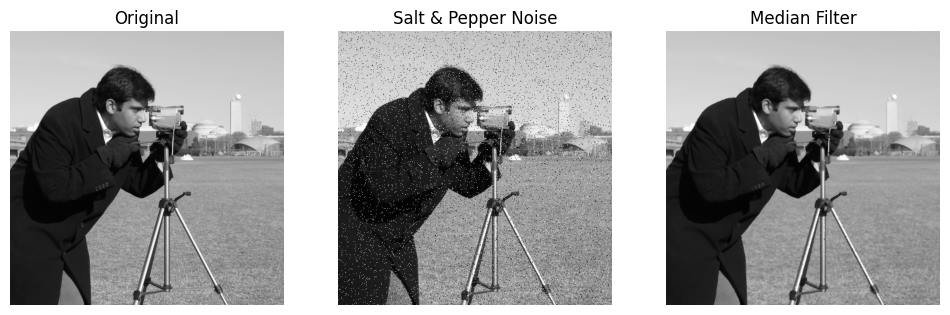

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.util import random_noise

# Load image
img = data.camera()

# Add Salt & Pepper Noise
noisy = random_noise(img, mode='s&p', amount=0.05)
noisy = (noisy * 255).astype(np.uint8)

# Median Filter
filtered = cv2.medianBlur(noisy, 3)

# Display
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(noisy, cmap='gray')
plt.title("Salt & Pepper Noise")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(filtered, cmap='gray')
plt.title("Median Filter")
plt.axis('off')

plt.show()

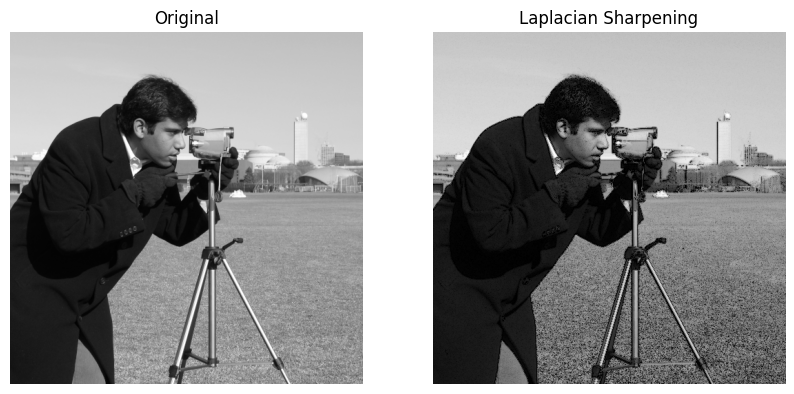

In [8]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

laplacian = cv2.Laplacian(img, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

sharp = cv2.addWeighted(img, 1.0, laplacian, -1.0, 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sharp, cmap='gray')
plt.title("Laplacian Sharpening")
plt.axis('off')

plt.show()

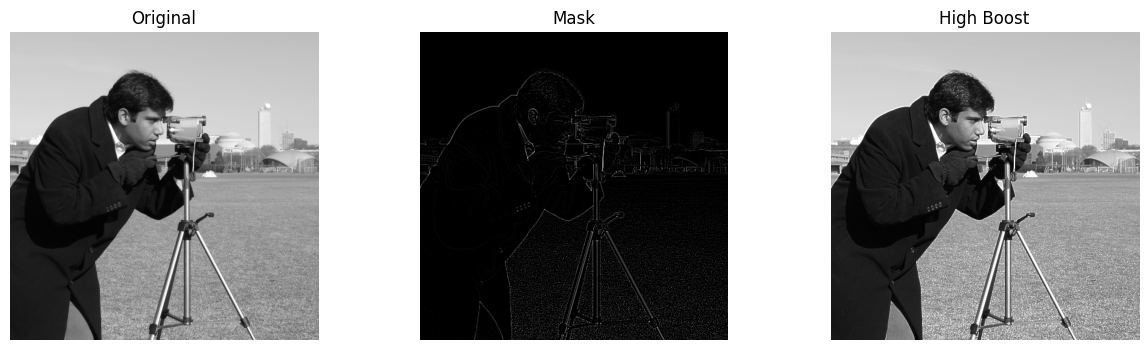

In [9]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

blur = cv2.GaussianBlur(img, (5,5), 0)

mask = cv2.subtract(img, blur)

k = 2.0

highboost = cv2.addWeighted(img, 1.0, mask, k, 0)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(highboost, cmap='gray')
plt.title("High Boost")
plt.axis('off')

plt.show()

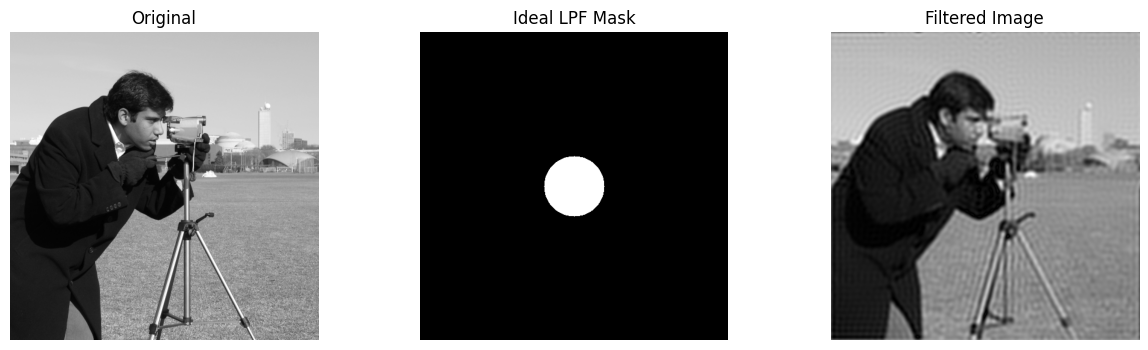

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

rows, cols = img.shape
crow, ccol = rows//2, cols//2

f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

mask = np.zeros((rows, cols), np.uint8)
radius = 50

Y, X = np.ogrid[:rows, :cols]
distance = (X-ccol)**2 + (Y-crow)**2
mask[distance <= radius**2] = 1

filtered = fshift * mask

result = np.fft.ifft2(np.fft.ifftshift(filtered))
result = np.abs(result)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Ideal LPF Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(result, cmap='gray')
plt.title("Filtered Image")
plt.axis('off')

plt.show()

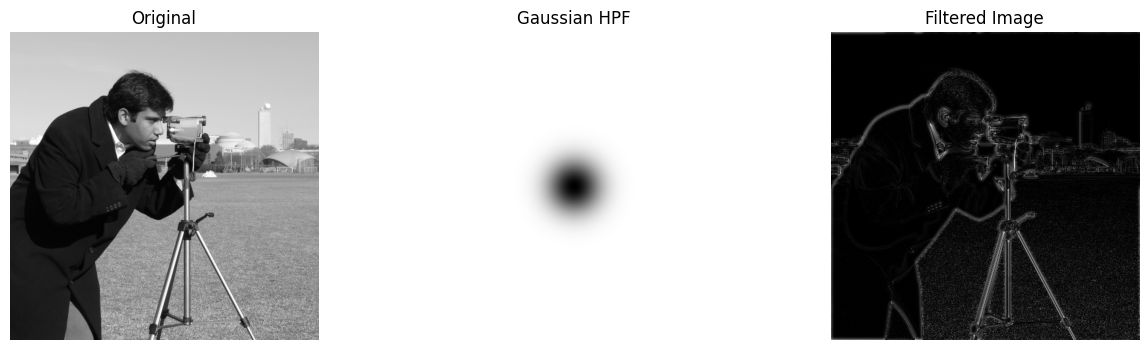

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

rows, cols = img.shape
crow, ccol = rows//2, cols//2

f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

D0 = 30

Y, X = np.ogrid[:rows, :cols]
D = np.sqrt((X-ccol)**2 + (Y-crow)**2)

H = 1 - np.exp(-(D**2)/(2*(D0**2)))

filtered = fshift * H

result = np.fft.ifft2(np.fft.ifftshift(filtered))
result = np.abs(result)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(H, cmap='gray')
plt.title("Gaussian HPF")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(result, cmap='gray')
plt.title("Filtered Image")
plt.axis('off')

plt.show()

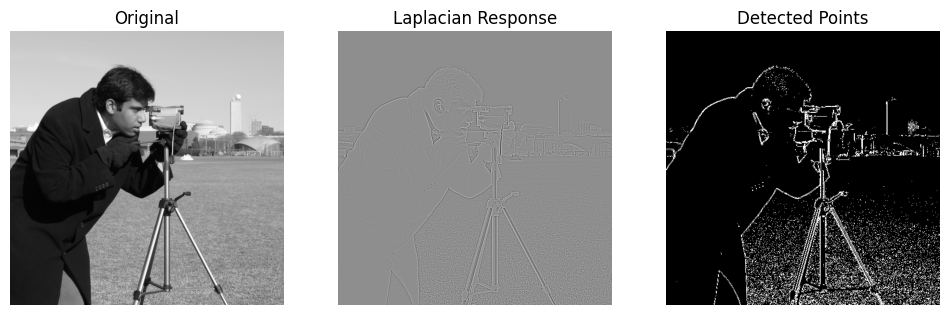

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Load image
img = data.camera()

# Laplacian Kernel
kernel = np.array([[1,1,1],
                   [1,-8,1],
                   [1,1,1]])

# Apply filter
response = cv2.filter2D(img, cv2.CV_64F, kernel)

# Threshold
threshold = 150
points = np.zeros_like(img)
points[np.abs(response) > threshold] = 255

# Display
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(response, cmap='gray')
plt.title("Laplacian Response")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(points, cmap='gray')
plt.title("Detected Points")
plt.axis('off')

plt.show()

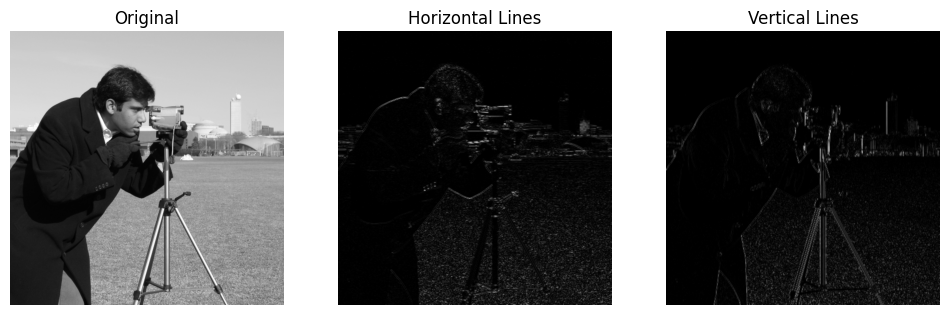

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

# Horizontal Line Mask
horizontal = np.array([[-1,-1,-1],
                       [ 2, 2, 2],
                       [-1,-1,-1]])

# Vertical Line Mask
vertical = np.array([[-1,2,-1],
                     [-1,2,-1],
                     [-1,2,-1]])

# Apply Filters
hor = cv2.filter2D(img, cv2.CV_64F, horizontal)
ver = cv2.filter2D(img, cv2.CV_64F, vertical)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(np.abs(hor), cmap='gray')
plt.title("Horizontal Lines")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(np.abs(ver), cmap='gray')
plt.title("Vertical Lines")
plt.axis('off')

plt.show()

Otsu Threshold Value: 102.0


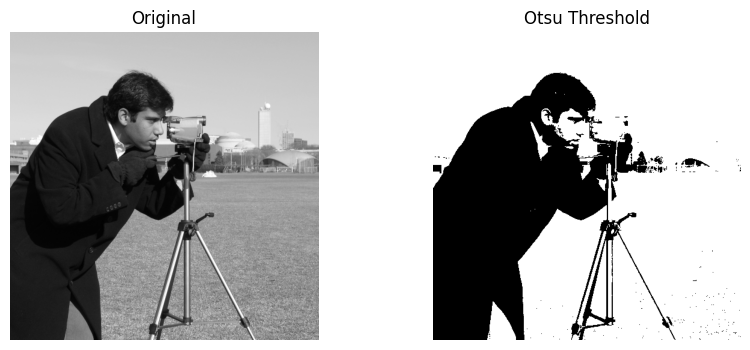

In [14]:
import cv2
import matplotlib.pyplot as plt
from skimage import data

img = data.camera()

threshold, binary = cv2.threshold(
    img,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu Threshold Value:", threshold)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(binary, cmap='gray')
plt.title("Otsu Threshold")
plt.axis('off')

plt.show()

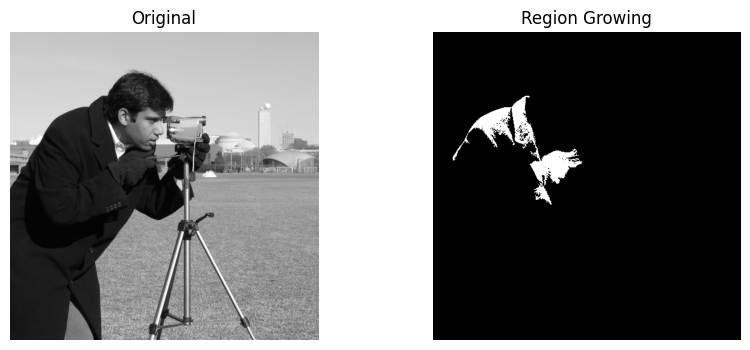

In [15]:
import matplotlib.pyplot as plt
from skimage import data
from skimage.segmentation import flood

img = data.camera()

# Seed Point
seed = (200, 200)

# Flood Fill
region = flood(img, seed_point=seed, tolerance=15)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(region, cmap='gray')
plt.title("Region Growing")
plt.axis('off')

plt.show()

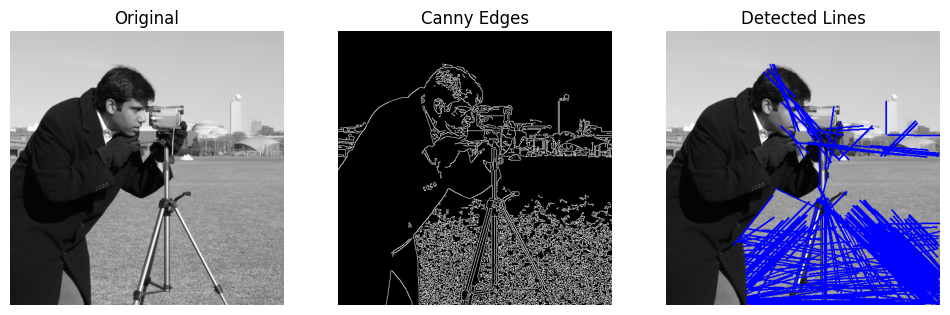

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Load sample image
img = data.camera()

# Edge Detection
edges = cv2.Canny(img, 50, 150)

# Hough Transform
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=100,
    minLineLength=50,
    maxLineGap=10
)

# Convert grayscale to color
output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Draw detected lines
if lines is not None:
    for line in lines:

        # Works for both OpenCV formats
        if len(line) == 1:
            x1, y1, x2, y2 = line[0]
        else:
            x1, y1, x2, y2 = line

        cv2.line(output, (x1, y1), (x2, y2), (255, 0, 0), 2)

# Display
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Lines")
plt.axis("off")

plt.show()